In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('FinancialMarketData.xlsx', sheet_name='EWS')
df

,Y,Data,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
0,0,2000-01-11,283.25,0.077,1388,157.2600,100.560,105.86,1.6460,25.77,...,116.4635,230.5267,123.7616,1416.12,127.75,990.59,856.76,224.33,217.34,34.30
1,0,2000-01-18,287.65,0.043,1405,165.0100,101.860,105.47,1.6383,28.85,...,117.2674,231.3770,123.7616,1428.79,129.50,993.98,925.22,234.37,227.08,32.74
2,0,2000-01-25,287.15,0.135,1368,167.2400,102.410,106.04,1.6496,28.28,...,117.9946,232.3895,123.7616,1385.93,126.48,974.83,886.93,216.82,233.00,32.46
3,0,2000-02-01,282.75,0.191,1311,166.8500,104.920,107.85,1.6106,28.22,...,120.5100,231.9417,122.3281,1385.31,129.19,1007.12,842.60,201.89,237.48,31.29
4,1,2000-02-08,298.40,0.312,1277,165.4300,104.220,109.30,1.6108,28.02,...,118.7914,237.8117,122.3281,1411.95,134.67,1034.58,945.15,218.00,258.02,31.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,2021-03-23,1727.96,0.339,2271,184.5022,92.336,108.72,1.3760,57.76,...,427.7972,1249.4030,389.8500,3800.77,140.32,1199.57,1671.73,681.21,1695.96,110.83
1107,0,2021-03-30,1685.56,0.303,2103,184.8741,93.297,110.29,1.3719,60.55,...,428.6578,1242.2640,385.8145,3835.96,142.76,1206.29,1635.57,693.38,1690.76,108.80
1108,0,2021-04-06,1743.28,0.440,2092,185.8393,92.335,109.88,1.3822,59.33,...,430.6649,1250.2560,390.6819,3955.16,144.13,1194.62,1689.62,673.20,1689.48,111.92
1109,0,2021-04-13,1742.69,0.467,2140,188.1368,91.852,109.19,1.3737,60.18,...,430.4087,1252.5630,390.3848,4027.05,144.23,1197.06,1680.82,680.23,1672.46,108.40


Text(0.5, 1.0, 'Distribution of Normal/Anomaly Label')

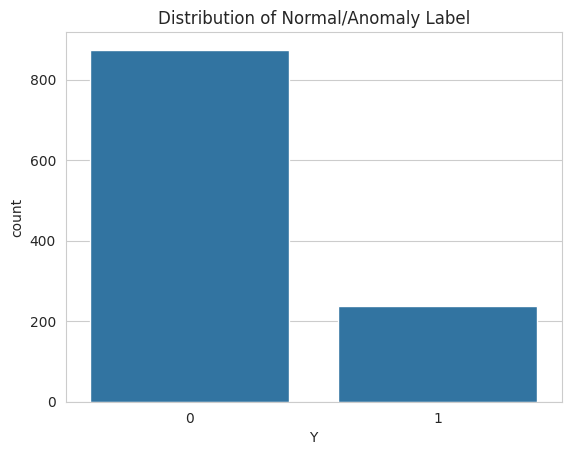

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Y', data=df)
plt.title("Distribution of Normal/Anomaly Label")

In [ ]:
# Identify index with high correlation to anomaly label 'Y'
correlations = df.corr()['Y'].sort_values(ascending=False)
correlations

,Y
Y,1.000000
VIX,0.598432
GTITL2YR,0.304528
GTITL10YR,0.297573
GTITL30YR,0.295000
EONIA,0.180311
GTDEM30Y,0.141537
GTDEM10Y,0.139933
GTJPY10YR,0.133660
GTDEM2Y,0.130607


In [ ]:
# VIX has Correlation coef > 0.5, worth investingating further for now
df_vix = df[['Data', 'VIX', 'Y']]
df_vix

,Data,VIX,Y
0,2000-01-11,22.50,0
1,2000-01-18,21.50,0
2,2000-01-25,23.02,0
3,2000-02-01,23.45,0
4,2000-02-08,21.25,1
...,...,...,...
1106,2021-03-23,20.30,0
1107,2021-03-30,19.61,0
1108,2021-04-06,18.12,0
1109,2021-04-13,16.65,0


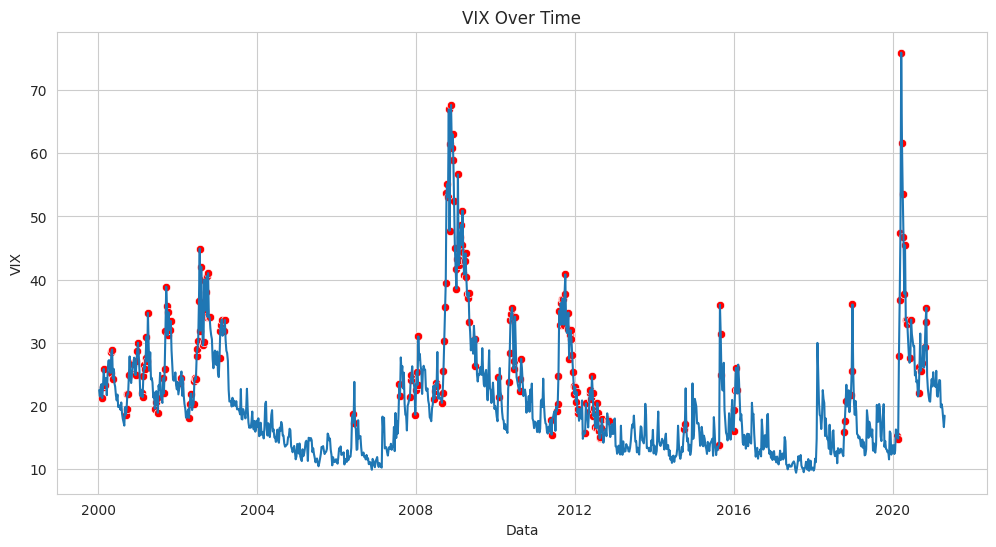

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_vix, x='Data', y='VIX')
anomaly = df_vix[df_vix['Y'] ==  1]
sns.scatterplot(data=anomaly, x='Data', y='VIX', color='red')
plt.title('VIX Over Time')
plt.show()

<ipython-input-7-c76b2284e007>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vix['Data'] = pd.to_datetime(df_vix['Data'])


<Axes: xlabel='Data', ylabel='VIX'>

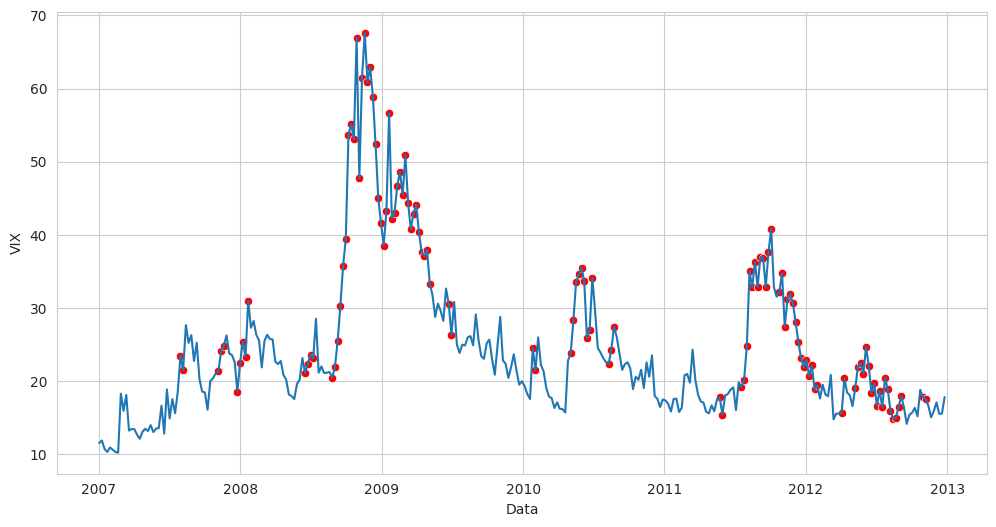

In [ ]:
# Example, zoom plot on 2007 to 2012
df_vix['Data'] = pd.to_datetime(df_vix['Data'])
plt.figure(figsize=(12, 6))
df_2007_2012 = df_vix[(df_vix['Data'] >= '2007-01-01') & (df_vix['Data'] <= '2012-12-31')]
sns.lineplot(data=df_2007_2012, x='Data', y='VIX')
sns.scatterplot(data=df_2007_2012[df_2007_2012['Y'] ==  1], x='Data', y='VIX', color='red')


# ARIMA

In [ ]:
''' ARIMA (AutoRegressive Integrated Moving Average) for univariate time series- observes only one varibale (VIX index) over time
ARIMA detects anomaly by detecting dât points that significally deviate from the expected values predicted by the model.
from statsmodels.tsa.arima.model import ARIMA '''

# Find p, d, q for ARIMA (following articles: https://analyticsindiamag.com/ai-trends/quick-way-to-find-p-d-and-q-values-for-arima/ and https://blog.devgenius.io/finding-optimal-p-d-and-q-values-for-your-arima-model-94669a909a35)
''' p: The number of lag observations included in the model (AR term).
    d: The number of times the data is differenced to make it stationary (I term).
    q: The size of the moving average window (MA term).'''
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_vix['VIX'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))


ADF Statistic: -3.971067
p-value: 0.001570
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


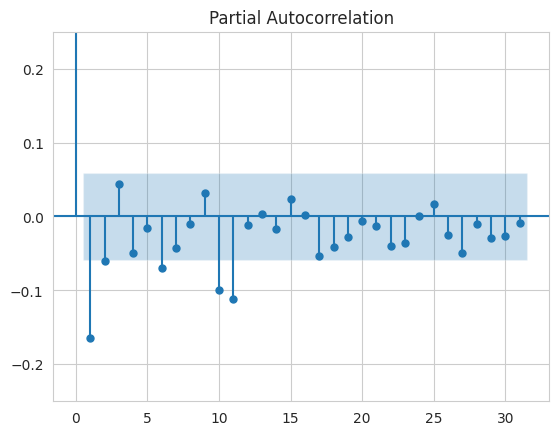

In [ ]:
# p-value less than < 0.05, inferring the series is stationary, and does not require differentiation => d = 0

# Find value for p
''' Using pacf plot with the following step
    1. Ignore the 0th one
    2. Check the antenna which is very close/inside to the dense part, and use the "n-1" formula '''
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_vix['VIX'].diff().dropna())
plt.ylim(-0.25, 0.25)
plt.show()


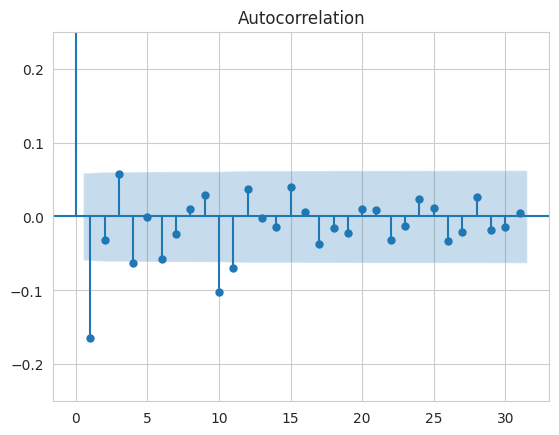

In [ ]:
# We can see first lag is significantly out of the limit and the second one is
# also out of the significant limit but it is not that far => p = 2-1 = 1

# Find value for q (similar process but with ACF plot)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_vix['VIX'].diff().dropna())
plt.ylim(-0.25, 0.25)
plt.show()
# q = 1

In [ ]:
# Building ARIMA model
from statsmodels.tsa.arima.model import ARIMA
train_size = int(len(df_vix) * 0.8)
tr_df = df_vix[:train_size]
ts_df = df_vix[train_size:]

# Fit the ARIMA model
model = ARIMA(tr_df['VIX'], order=(1, 0, 1))
arima_fit = model.fit()
arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    VIX   No. Observations:                  888
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2181.853
Date:                Sun, 12 Jan 2025   AIC                           4371.706
Time:                        20:49:25   BIC                           4390.862
Sample:                             0   HQIC                          4379.028
                                - 888                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.1785      2.820      7.156      0.000      14.652      25.705
ar.L1          0.9660      0.006    166.141      0.000       0.955       0.977
ma.L1         -0.2398      0.021    -11.494      0.000      -0.281      -0.199
sigma2         7.9540      0.186     42.700      0.000       7.589       8.319
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              3074.68
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.29   Skew:                             1.46
Prob(H) (two-sided):                  0.03   Kurtosis:                        11.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

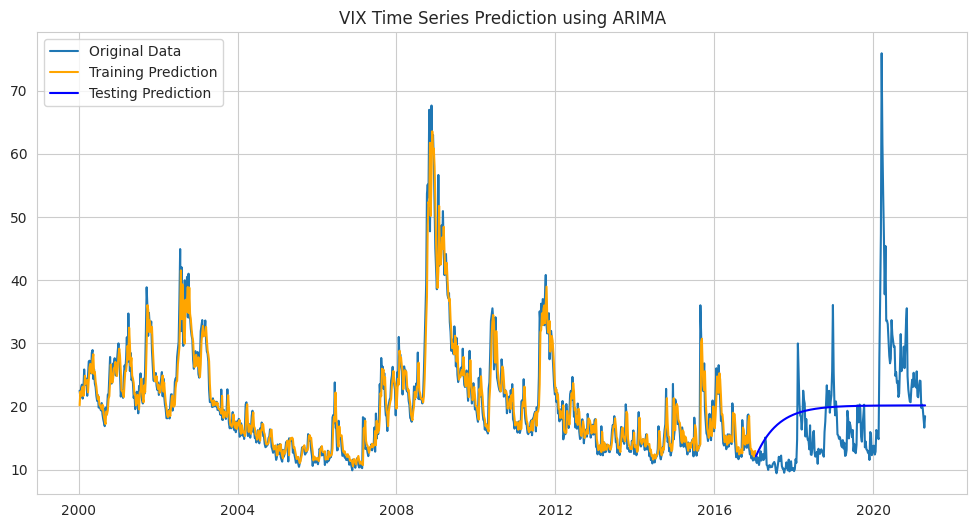

In [ ]:
# Make predictions
tr_pred = arima_fit.predict(start=0, end=len(tr_df) - 1)
ts_pred = arima_fit.predict(start=len(tr_df), end=len(df_vix) - 1)

# Plot original data and predicted data, training prediction orange, testing prediction is blue
plt.figure(figsize=(12, 6))
plt.plot(df_vix['Data'], df_vix['VIX'], label='Original Data')
plt.plot(tr_df['Data'], tr_pred, color='orange', label='Training Prediction')
plt.plot(ts_df['Data'], ts_pred, color='blue', label='Testing Prediction')
plt.title('VIX Time Series Prediction using ARIMA')
plt.legend()

In [ ]:
history = [x for x in tr_df['VIX'][800:]]
predictions = list()
anomalies = list()
# Walk-forward validation
for i in range(len(ts_df)):
    model = ARIMA(history, order=(1, 0, 1))
    model_fit = model.fit()

    # Forecast the next VIX value
    output = model_fit.forecast(n_periods=1)[0]
    predictions.append(output)
    # The actual observe VIX value
    obs = ts_df['VIX'].iloc[i]

    residual = obs - output
    # Mark as anomaly if residual is larger than the threshold
    threshold = model_fit.resid.std() * 2   # 2 standard deviations threshold
    if abs(residual) > threshold:
        anomalies.append(1)  # Anomaly
    else:
        anomalies.append(0)  # Normal

    # Append new observation (actual data) to history for ARIMA model in the next day
    history.append(obs)
    history.pop(0) # Removes the first element to keep the length constant, remove data that is too old

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['n_periods']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


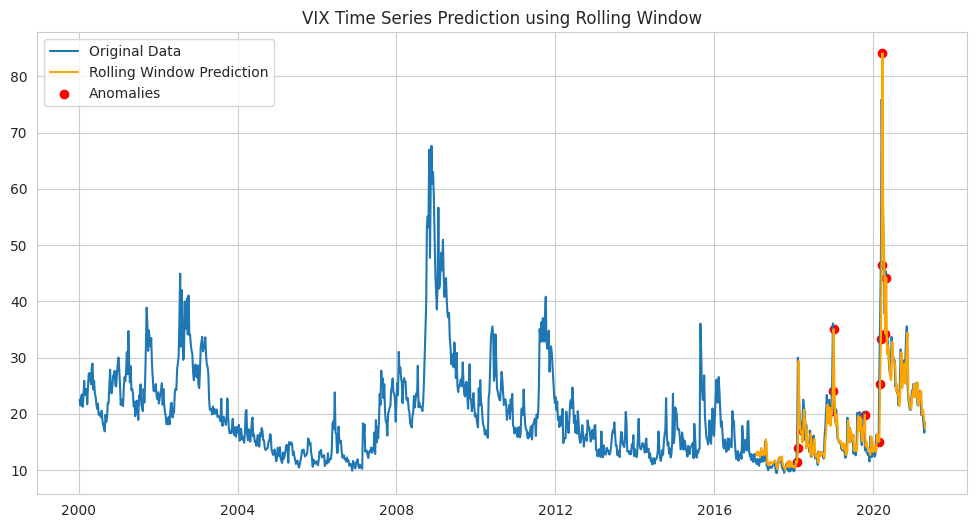

In [ ]:
# Add predictions and anomalies to the dataframe
predictions_df = pd.DataFrame({
    'Date': ts_df['Data'],
    'Predicted': predictions,
    'Anomaly': anomalies
})

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_vix['Data'], df_vix['VIX'], label='Original Data')
plt.plot(predictions_df['Date'], predictions_df['Predicted'], color='orange', label='Rolling Window Prediction')
plt.scatter(predictions_df[predictions_df['Anomaly'] == 1]['Date'], predictions_df[predictions_df['Anomaly'] == 1]['Predicted'], color='red', label='Anomalies')
plt.title('VIX Time Series Prediction using Rolling Window')
plt.legend()

## ARIMA for whole data set

In [ ]:
history = [x for x in df_vix['VIX'][:30]]
predictions = list()
anomalies = list()
# Walk-forward validation
for i in range(30, len(df_vix)):
    model = ARIMA(history, order=(1, 0, 1))
    model_fit = model.fit()

    # Forecast the next VIX value
    output = model_fit.forecast(n_periods=1)[0]
    predictions.append(output)
    # The actual observe VIX value
    obs = df_vix['VIX'].iloc[i]

    residual = obs - output
    # Mark as anomaly if residual is larger than the threshold
    threshold = model_fit.resid.std() * 2   # 2 standard deviations threshold
    if abs(residual) > threshold:
        anomalies.append(1)  # Anomaly
    else:
        anomalies.append(0)  # Normal

    # Append new observation (actual data) to history for ARIMA model in the next day
    history.append(obs)
    history.pop(0) # Removes the first element to keep the length constant, remove data that is too old

ARIMA based algorithms vs neural networks in anomaly detection, https://eyer.ai/blog/arima-based-algorithms-vs-neural-networks-in-anomaly-detection/

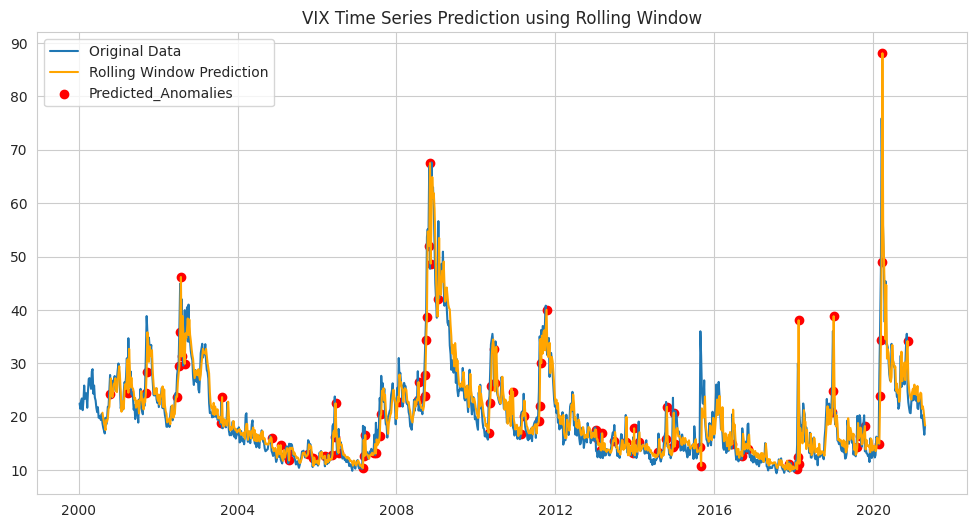

In [ ]:
# Add predictions and anomalies to the dataframe
predictions_df = pd.DataFrame({
    'Date': df_vix['Data'][30:],
    'Predicted': predictions,
    'Anomaly': anomalies
})

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_vix['Data'], df_vix['VIX'], label='Original Data')
plt.plot(predictions_df['Date'], predictions_df['Predicted'], color='orange', label='Rolling Window Prediction')
plt.scatter(predictions_df[predictions_df['Anomaly'] == 1]['Date'], predictions_df[predictions_df['Anomaly'] == 1]['Predicted'], color='red', label='Predicted_Anomalies')
plt.title('VIX Time Series Prediction using Rolling Window')
plt.legend()

In [ ]:
# Evaluate the Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report
mse = mean_squared_error(df_vix['VIX'][30:], predictions)
mae = mean_absolute_error(df_vix['VIX'][30:], predictions)
print(classification_report(df_vix['Y'][30:], anomalies))
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       852
           1       0.39      0.15      0.22       229

    accuracy                           0.77      1081
   macro avg       0.60      0.54      0.54      1081
weighted avg       0.72      0.77      0.73      1081

Mean Squared Error: 11.58767125792018
Mean Absolute Error: 2.158251989501136


# Different AI/ML algorithim with multivariable

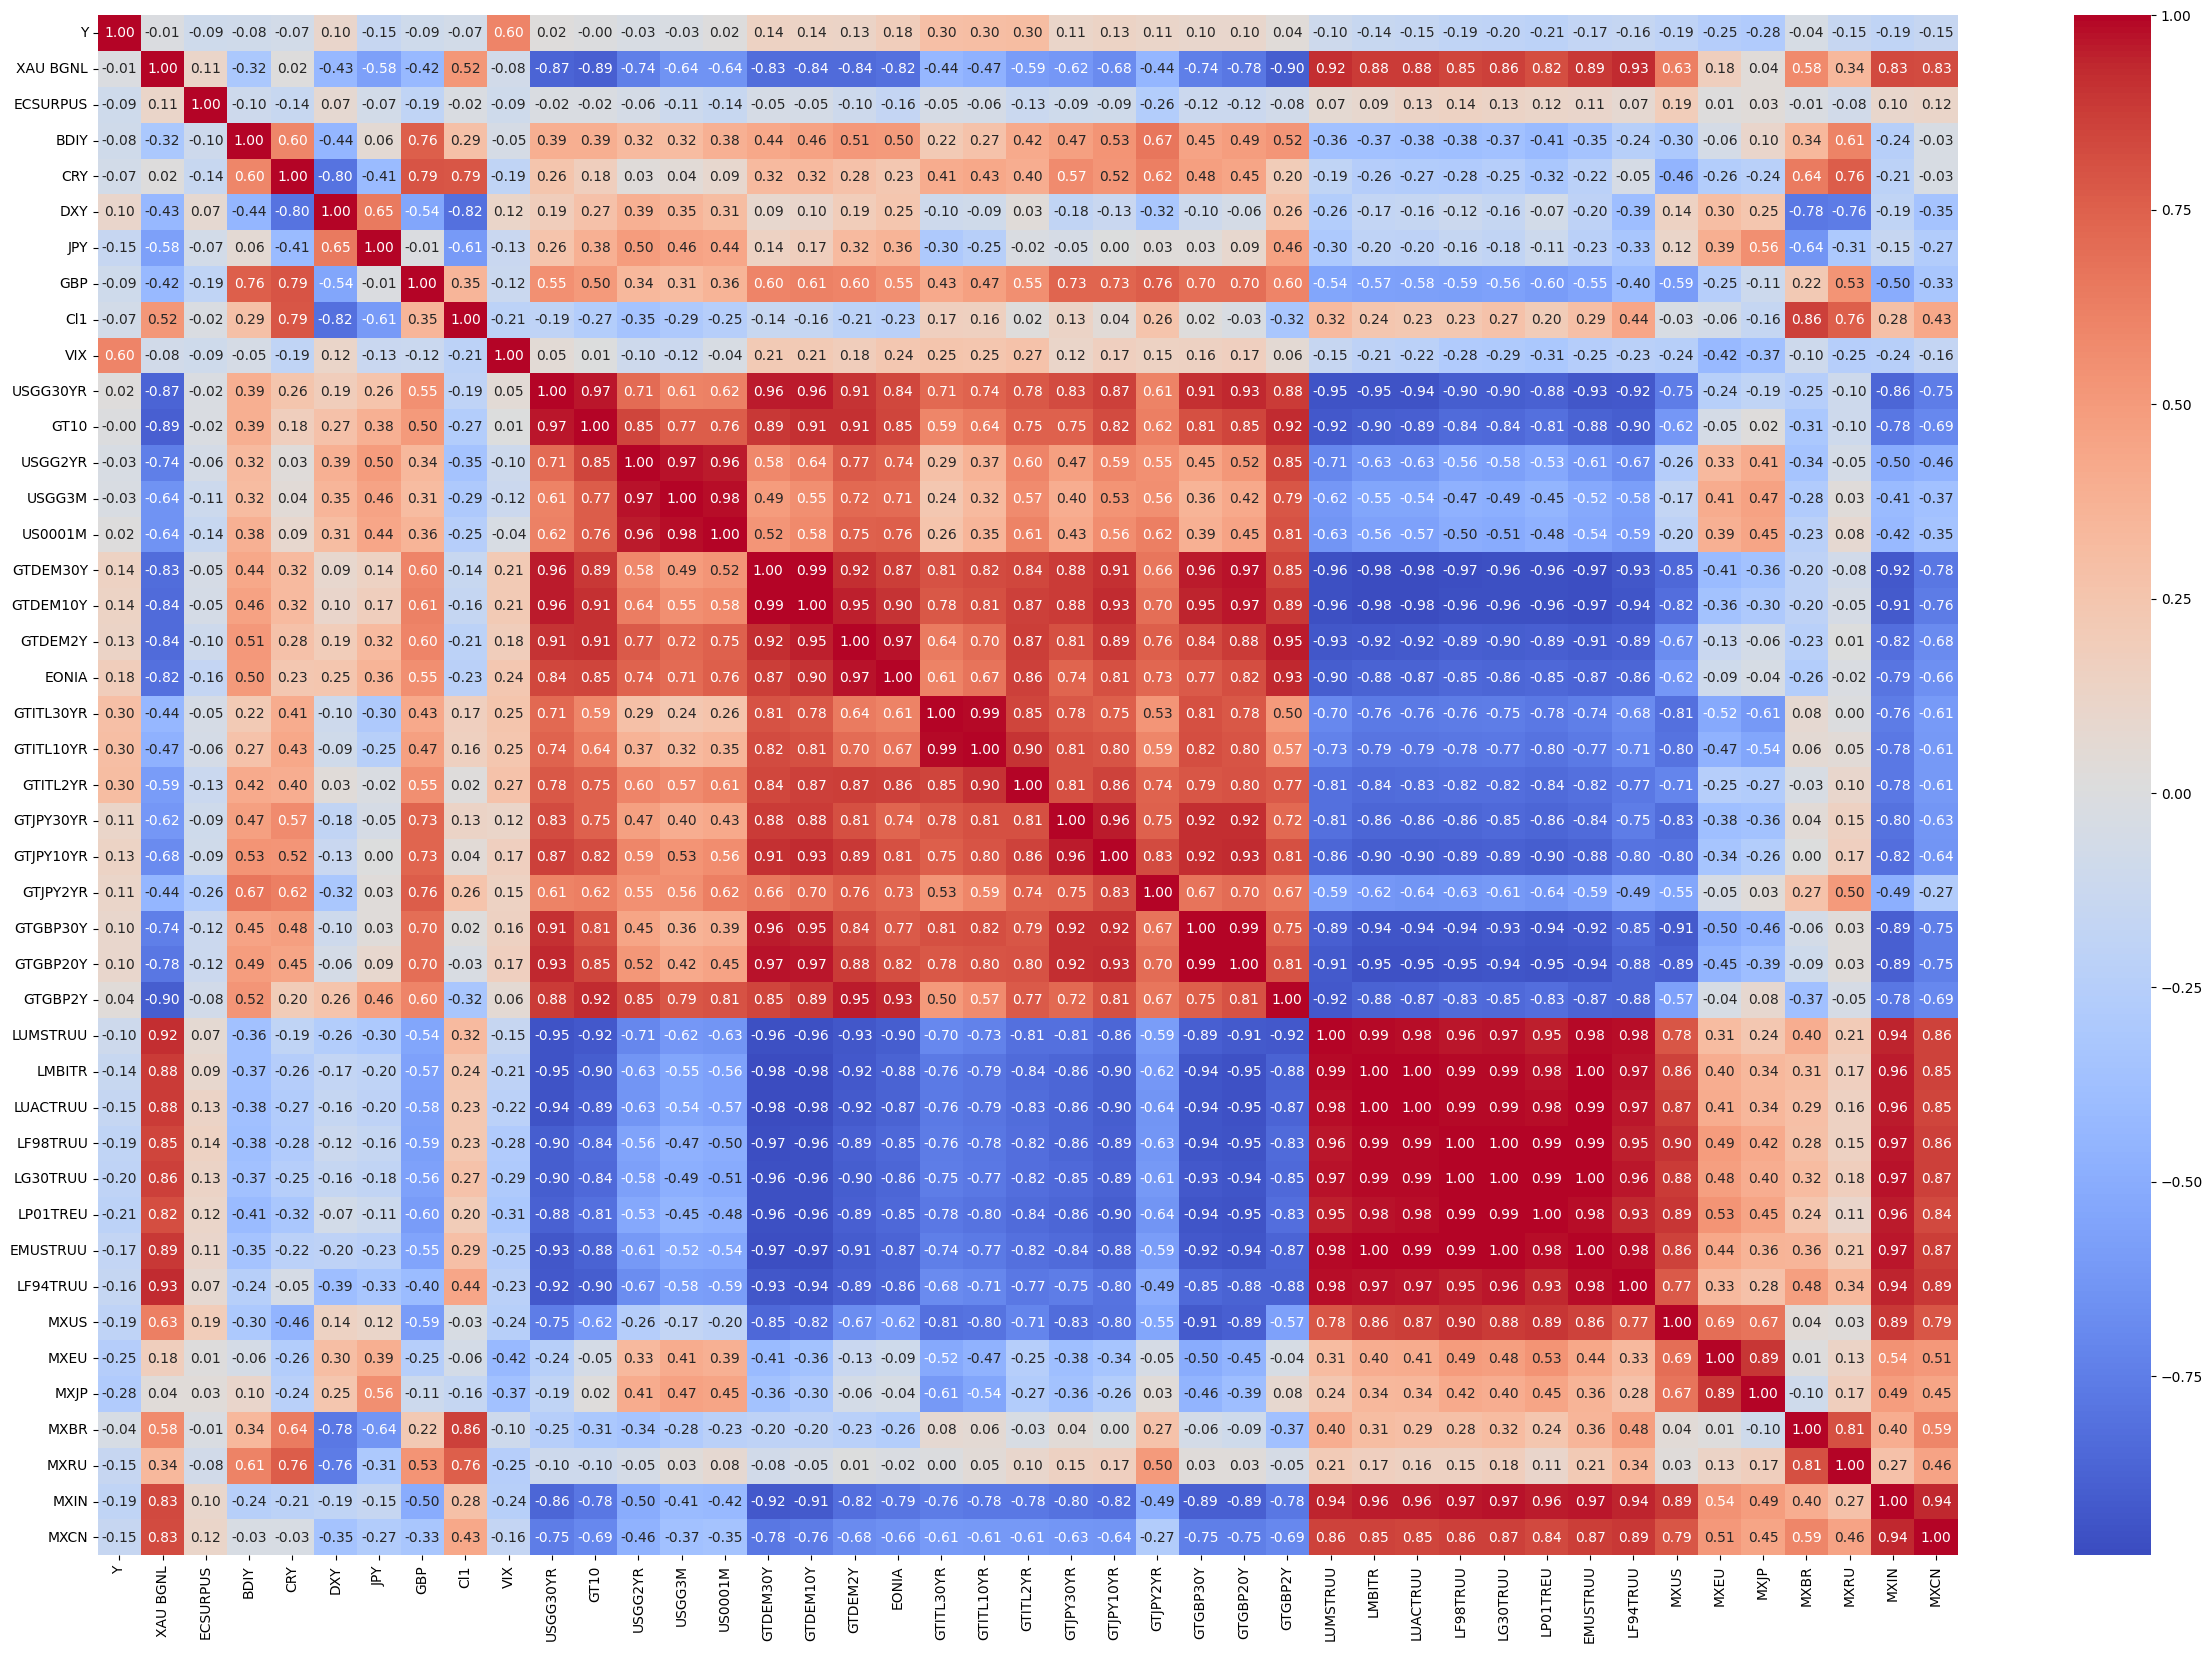

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation between all columns (except the date 'Data' column)
correlation_matrix = df.drop(columns=['Data']).corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(30, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [ ]:
# Indices in the same highly correlated. For example,
# 1. Bond indices (global, corporate IG/HY, inflation-linked, municipals, mortgages): LUMSTRUU, LMBITR, LUACTRUU, LF98TRUU, LG30TRUU, LP01TREU, EMUSTRUU, LF94TRUU
# 2. Short/medium/long term interest rates (especially ones from the same country): USGG30YR, GT10, USGG2YR, USGG3M, US0001M, GTDEM30Y, GTDEM10Y, GTDEM2Y, EONIA, GTITL30YR, GTITL10YR, GTITL2YR, GTJPY30YR, GTJPY10YR, GTJPY2YR, GTGBP30Y, GTGBP20Y, GTGBP2Y
# 3. Gold spot (XAU BGNL) highly correlated to bond indices

# Feature selection
# Based on correlation matrix, I decided to choose 'VIX', 'GTITL2YR', 'EONIA', 'GTDEM30Y', 'LP01TREU', 'MXJP' as the variables for the multivariables model.
# Below are some variable with high correlation with 'Y':
'''
VIX	        0.598432
GTITL2YR	0.304528
GTITL10YR	0.297573
GTITL30YR	0.295000
EONIA	    0.180311
GTDEM30Y	0.141537
LP01TREU    -0.209774
MXEU	    -0.253877
MXJP	    -0.279399
'''
# However, GTITL2YR, GTITL10YR and GTITL30YR are highly correlated, same for MXEU and MXJP. Thus to avoid multiliearity, variables in models can't have high corelation.

# LSTM RNN

In [57]:
# Train, test time-series split
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
df_multifeatures = df[['Data', 'VIX', 'GTITL2YR', 'EONIA', 'GTDEM30Y', 'LP01TREU', 'MXJP', 'Y']]
for train_index, test_index in tscv.split(df_multifeatures):
    train_df = df_multifeatures.iloc[train_index]
    test_df = df_multifeatures.iloc[test_index]
train_df.shape, test_df.shape
df_multifeatures.head()

,Data,VIX,GTITL2YR,EONIA,GTDEM30Y,LP01TREU,MXJP,Y
0,2000-01-11,22.50,4.495,2.89,6.121,116.4635,990.59,0
1,2000-01-18,21.50,4.535,3.03,6.254,117.2674,993.98,0
2,2000-01-25,23.02,4.511,3.15,6.045,117.9946,974.83,0
3,2000-02-01,23.45,4.540,3.30,5.944,120.5100,1007.12,0
4,2000-02-08,21.25,4.638,3.26,5.850,118.7914,1034.58,1


In [ ]:
# Scale train_df and test_df
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df.drop(columns=['Data', 'Y']))
test_scaled = scaler.transform(test_df.drop(columns=['Data', 'Y']))
train_scaled.shape, test_scaled.shape

((926, 6), (185, 6))

In [ ]:
'''Prepare Input Data for LSTM
LSTM is a bit more demanding than other models. The input data to an LSTM model is a 3-dimensional array.
The shape of the array should be [samples, TIME_STEPS, features]'''

TIME_STEPS = 30

def create_sequences(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(train_scaled, train_df['Y'].values)
X_test, y_test = create_sequences(test_scaled, test_df['Y'].values)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((896, 30, 6), (896,), (155, 30, 6), (155,))

In [ ]:
# Build Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, RepeatVector, BatchNormalization, Bidirectional
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True)),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, activation='tanh', return_sequences=False),
    BatchNormalization(),
    Dropout(0.1),
    Dense(units=1, activation='sigmoid')  # Binary classification output
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall()])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional)      │ (None, 30, 128)             │          36,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 30, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 57,633 (225.13 KB)

 Trainable params: 57,313 (223.88 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
# Train the Model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.7092 - loss: 0.6867 - precision_2: 0.4480 - recall_2: 0.7140 - val_accuracy: 0.9778 - val_loss: 0.4835 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7902 - loss: 0.4653 - precision_2: 0.6038 - recall_2: 0.6844 - val_accuracy: 0.9778 - val_loss: 0.4196 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8156 - loss: 0.4237 - precision_2: 0.5906 - recall_2: 0.7237 - val_accuracy: 0.9778 - val_loss: 0.3550 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8379 - loss: 0.4052 - precision_2: 0.6260 - recall_2: 0.7030 - val_accuracy: 0.9778 - val_loss: 0.3062 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8226 - loss: 0.4067 - precisi

In [ ]:
# Evaluate the model with classification report
y_pred = model.predict(X_train)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_train, y_pred))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       696
           1       0.90      0.91      0.90       200

    accuracy                           0.96       896
   macro avg       0.94      0.94      0.94       896
weighted avg       0.96      0.96      0.96       896



In [ ]:
# Evaluate the model with classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       126
           1       0.29      0.28      0.28        29

    accuracy                           0.74       155
   macro avg       0.56      0.56      0.56       155
weighted avg       0.73      0.74      0.73       155



# Test model with data from 2021 until now

In [ ]:
'''
For VIX: https://www.cboe.com/tradable_products/vix/vix_historical_data/
For GTITL2YR: https://www.investing.com/rates-bonds/italy-2-year-bond-yield-historical-data?utm_source=chatgpt.com
For EONIA: https://data.ecb.europa.eu/data/datasets/EST/EST.B.EU000A2X2A25.WT?chart_props=W3sibm9kZUlkIjoiMTg5NzI0MiIsInByb3BlcnRpZXMiOlt7ImNvbG9ySGV4IjoiIiwiY29sb3JUeXBlIjoiIiwiY2hhcnRUeXBlIjoibGluZWNoYXJ0IiwibGluZVN0eWxlIjoiU29saWQiLCJsaW5lV2lkdGgiOiIxLjUiLCJheGlzUG9zaXRpb24iOiJsZWZ0Iiwib2JzZXJ2YXRpb25WYWx1ZSI6ZmFsc2UsImRhdGVzIjpbIjIwMjEtMDQtMDFUMDQ6MDA6MDAuMDAwWiIsIjIwMjUtMDEtMDlUMDU6MDA6MDAuMDAwWiJdLCJpc1RkYXRhIjpmYWxzZSwibW9kaWZpZWRVbml0VHlwZSI6IiIsInllYXIiOiJkYXRld2lzZSIsInN0YXJ0RGF0ZSI6IjIwMjEtMDMtMzEiLCJlbmREYXRlIjoiMjAyNS0wMS0wOCIsInNldERhdGUiOnRydWUsInNob3dUYWJsZURhdGEiOmZhbHNlLCJjaGFuZ2VNb2RlIjpmYWxzZSwic2hvd01lbnVTdHlsZUNoYXJ0IjpmYWxzZSwiZGlzcGxheU1vYmlsZUNoYXJ0Ijp0cnVlLCJzY3JlZW5TaXplIjoibWF4Iiwic2NyZWVuV2lkdGgiOjk1OCwic2hvd1RkYXRhIjpmYWxzZSwidHJhbnNmb3JtZWRGcmVxdWVuY3kiOiJub25lIiwidHJhbnNmb3JtZWRVbml0Ijoibm9uZSIsImZyZXF1ZW5jeSI6Im5vbmUiLCJ1bml0Ijoibm9uZSIsIm1vZGlmaWVkIjoiZmFsc2UiLCJzZXJpZXNLZXkiOiJkYWlseSAtIGJ1c2luZXNzd2VlayIsInNob3d0YWJsZVN0YXRlQmVmb3JlTWF4U2NyZWVuIjpmYWxzZSwiaXNkYXRhY29tcGFyaXNvbiI6ZmFsc2UsInNlcmllc0ZyZXF1ZW5jeSI6ImRhaWx5IC0gYnVzaW5lc3N3ZWVrIiwiaW50aWFsU2VyaWVzRnJlcXVlbmN5IjoiZGFpbHkgLSBidXNpbmVzc3dlZWsiLCJtZXRhZGF0YURlY2ltYWwiOiIzIiwiaXNUYWJsZVNvcnRlZCI6ZmFsc2UsImlzWWVhcmx5VGRhdGEiOmZhbHNlLCJyZXNwb25zZURhdGFFbmREYXRlIjoiIiwiaXNpbml0aWFsQ2hhcnREYXRhIjp0cnVlLCJpc0RhdGVzRnJvbURhdGVQaWNrZXIiOnRydWUsImRhdGVQaWNrZXJFbmREYXRlIjoiMjAyNS0wMS0wOSIsImlzRGF0ZVBpY2tlckVuZERhdGUiOnRydWUsInNlcmllc2tleVNldCI6IiIsImRhdGFzZXRJZCI6IjI5NyIsImlzQ2FsbGJhY2siOmZhbHNlLCJpc1NsaWRlclRkYXRhIjp0cnVlLCJpc1NsaWRlckRhdGEiOnRydWUsImlzSW5pdGlhbENoYXJ0RGF0YUZyb21HcmFwaCI6dHJ1ZSwiY2hhcnRTZXJpZXNLZXkiOiJFU1QuQi5FVTAwMEEyWDJBMjUuV1QiLCJ0eXBlT2YiOiJkb3duTG9hZCJ9XX1d
For GTDEM30Y: https://www.investing.com/rates-bonds/germany-30-year-bond-yield-historical-data
For LP01TREU: https://www.investing.com/funds/lu2301396102-historical-data
For MXJP:  https://www.investing.com/etfs/msci-japan-source-historical-data
'''


In [55]:
# Load Testing data
df_test = pd.read_excel('TestingData2021-2024.xlsx', sheet_name='Testing data')
df_test

,Data,VIX,GTITL2YR,EONIA,GTDEM30Y,LP01TREU,MXJP
0,2021-04-27,17.62,-0.314,-0.560,0.357,100.116,75.81
1,2021-05-04,18.16,-0.210,-0.564,0.347,100.085,74.12
2,2021-05-11,21.17,-0.241,-0.564,0.438,100.038,75.82
3,2021-05-18,18.89,-0.318,-0.558,0.424,100.116,73.46
4,2021-05-25,18.35,-0.355,-0.565,0.383,100.107,74.46
...,...,...,...,...,...,...,...
186,2024-12-09,13.36,2.405,3.165,2.475,105.895,81.61
187,2024-12-16,14.37,2.389,3.164,2.520,105.033,79.48
188,2024-12-23,18.09,2.418,2.919,2.622,104.847,80.98
189,2024-12-31,17.39,2.503,2.915,2.654,105.157,80.11


In [58]:
# Scale test data
test_scaled = scaler.transform(df_test.drop(columns=['Data']))

# Prepare data for the model
TIME_STEPS = 30

def create_sequences(X,time_steps=TIME_STEPS):
    Xs = []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
    return np.array(Xs)

X_2021_2024_test = create_sequences(test_scaled)
X_2021_2024_test.shape

(161, 30, 6)

In [70]:
# Create Y variable that predict anomaly
y_pred = model.predict(X_2021_2024_test)
y_pred = (y_pred > 0.4).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [71]:
# Add Y variable to df set it to Not a number
df_test['Y'] = np.nan
df_test.loc[30:, 'Y'] = y_pred
df_test = df_test.dropna()
df_test

,Data,VIX,GTITL2YR,EONIA,GTDEM30Y,LP01TREU,MXJP,Y
30,2021-11-29,25.31,-0.283,-0.574,-0.086,100.460,77.50,0.0
31,2021-12-06,28.99,-0.301,-0.575,-0.041,100.748,74.09,0.0
32,2021-12-13,19.29,-0.287,-0.577,-0.029,101.060,74.27,0.0
33,2021-12-20,25.89,-0.127,-0.577,0.120,101.143,75.72,0.0
34,2021-12-28,17.78,-0.074,-0.571,0.200,101.196,75.29,0.0
...,...,...,...,...,...,...,...,...
186,2024-12-09,13.36,2.405,3.165,2.475,105.895,81.61,0.0
187,2024-12-16,14.37,2.389,3.164,2.520,105.033,79.48,0.0
188,2024-12-23,18.09,2.418,2.919,2.622,104.847,80.98,0.0
189,2024-12-31,17.39,2.503,2.915,2.654,105.157,80.11,0.0


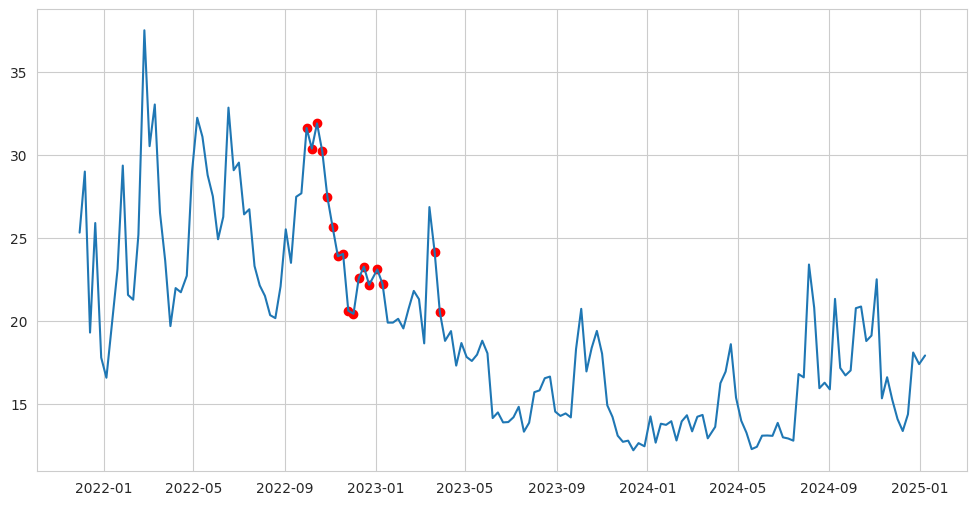

In [72]:
# Graph VIX time-series
plt.figure(figsize=(12, 6))
plt.plot(df_test['Data'], df_test['VIX'], label='VIX')
# Scatter plot for anomaly
anomaly = df_test[df_test['Y'] == 1]
plt.scatter(anomaly['Data'], anomaly['VIX'], color='red', label='Anomaly')


In [ ]:
# The model likely requires enhancement and continuous training to improve its performance.
# Currently, it can only detect anomalies up to the year 2023. To ensure accurate anomaly
# detection for 2024 and 2025, we should consider retraining the model with updated data that
# includes more recent information.

# However the model detects some anomaly from the period from September 2022 to January 2023
# Here is some information about these detected anomlies
'''
The period from September 2022 to January 2023 saw significant market anomalies driven by a mix of macroeconomic, geopolitical, and financial factors. Here are some notable events and trends during this time:

1. Persistently High Inflation
Inflation remained high in many parts of the world, particularly in the United States, Europe, and the UK, leading to aggressive monetary tightening by central banks.
The U.S. Federal Reserve raised interest rates multiple times, with a 75-basis-point hike in November 2022 and another 50-basis-point hike in December 2022.
High inflation and rising interest rates impacted equity and bond markets, increasing volatility.
2. Energy Crisis in Europe
Europe faced an energy crisis due to the ongoing Russia-Ukraine war, leading to record-high energy prices.
Gas shortages and reliance on alternative energy imports disrupted markets, particularly in the industrial and utility sectors.
Energy stocks often outperformed during this period, while energy-intensive industries faced challenges.
3. Cryptocurrency Market Volatility
The cryptocurrency market experienced a major anomaly with the collapse of FTX in November 2022, a leading cryptocurrency exchange.
The failure of FTX led to billions of dollars in losses and shook investor confidence in the crypto space.
Bitcoin and other major cryptocurrencies fell sharply, and the industry faced increased scrutiny from regulators.
4. Stock Market Trends
U.S. stock markets exhibited high volatility, influenced by Federal Reserve rate hikes and concerns about a potential recession.
Growth stocks, particularly in the tech sector, underperformed due to rising interest rates and declining valuations.
Defensive sectors such as healthcare and consumer staples performed relatively better.
5. Bond Market Anomalies
The bond market saw an inverted yield curve, with short-term yields exceeding long-term yields, signaling potential recession fears.
U.S. 10-year Treasury yields rose to their highest levels since 2008, reflecting uncertainty and inflation concerns.
6. Dollar Strength
The U.S. Dollar Index (DXY) reached 20-year highs in late 2022, driven by the Fed's aggressive monetary policy and global risk aversion.
A strong dollar negatively impacted emerging markets and U.S. multinational corporations relying on foreign revenue.
7. China's Economic Challenges
China's strict COVID-19 lockdown measures and a struggling property sector disrupted its economic recovery.
The reopening of China in late December 2022, following the rollback of zero-COVID policies, marked a turning point, influencing global markets.
8. Labor Market Resilience
Despite economic uncertainty, the U.S. labor market remained strong, with low unemployment rates and high wage growth, contributing to inflationary pressures.
9. Seasonal Trends
The "Santa Claus rally" (a common end-of-year stock market rally) was muted in December 2022 due to broader macroeconomic concerns and bearish sentiment.
These anomalies created significant challenges and opportunities for investors, reshaping strategies in equities, fixed income, and alternative assets.
'''

In [ ]:
# A investment strategy can be proposed using the model's predictions, focusing on minimizing losses and maximizing returns
'''
Create a Stop-Loss and Take-Profit System: since anomalies could be either positive (unusual spikes)
or negative (crashes), it can be hard to determine the specific action (sell or buy). Instead, use:
    * Stop-Loss Mechanism: Automatically sell assets if the model predicts significant downside risk, reducing potential losses.
    * Take-Profit Triggers: Lock in profits when the model identifies peak performance or signals potential downturns.
'''

# However the model need Continuous Feedback Loop that Continuously update the model with real-time data to incorporate the latest market trends and anomalies for more accurate predictions.

The